In [70]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

ROOT = Path.home() / "Documents" / "customer-churn-retention"
df = pd.read_csv(ROOT / "data" / "processed" / "features_segmented.csv")

target = "churn_value"
drop_cols = ["customer_id", "city", "state", "segment", "segment_name",
             "contract_num", "cltv", target]
X = df.drop(columns=drop_cols)
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.mean().round(3), y_val.mean().round(3), y_test.mean().round(3))

(4930, 18) (1056, 18) (1057, 18)
0.265 0.265 0.266


In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

def evaluate(name, model):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {"model": name,
            "ROC-AUC": round(roc_auc_score(y_val, proba), 3),
            "PR-AUC": round(average_precision_score(y_val, proba), 3),
            "Recall": round(recall_score(y_val, pred), 3),
            "Precision": round(precision_score(y_val, pred, zero_division=0), 3)}

results = []
results.append(evaluate("Baseline (dummy)", Pipeline([("prep", preprocess),
                        ("clf", DummyClassifier(strategy="prior"))])))
results.append(evaluate("Logistic Regression", Pipeline([("prep", preprocess),
                        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])))
pd.DataFrame(results)

,model,ROC-AUC,PR-AUC,Recall,Precision
0,Baseline (dummy),0.500,0.265,0.000,0.000
1,Logistic Regression,0.859,0.693,0.789,0.526


In [72]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

rf = Pipeline([("prep", preprocess),
               ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                              class_weight="balanced", random_state=42, n_jobs=-1))])

xgb = Pipeline([("prep", preprocess),
                ("clf", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                      subsample=0.8, colsample_bytree=0.8,
                                      scale_pos_weight=scale_pos, eval_metric="logloss",
                                      random_state=42))])

results.append(evaluate("Random Forest", rf))
results.append(evaluate("XGBoost", xgb))
pd.DataFrame(results)

,model,ROC-AUC,PR-AUC,Recall,Precision
0,Baseline (dummy),0.500,0.265,0.000,0.000
1,Logistic Regression,0.859,0.693,0.789,0.526
2,Random Forest,0.853,0.674,0.721,0.529
3,XGBoost,0.865,0.710,0.779,0.527


In [73]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    "clf__n_estimators": [200, 300, 500],
    "clf__max_depth": [2, 3, 4, 5],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__subsample": [0.7, 0.8, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0],
    "clf__min_child_weight": [1, 3, 5],
}

search = RandomizedSearchCV(
    xgb, param_dist, n_iter=25, scoring="average_precision",
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

print("Best CV PR-AUC:", round(search.best_score_, 3))
print(search.best_params_)

best_xgb = search.best_estimator_
results.append(evaluate("XGBoost (tuned)", best_xgb))
pd.DataFrame(results)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV PR-AUC: 0.677
{'clf__subsample': 0.8, 'clf__n_estimators': 300, 'clf__min_child_weight': 1, 'clf__max_depth': 4, 'clf__learning_rate': 0.03, 'clf__colsample_bytree': 0.8}


,model,ROC-AUC,PR-AUC,Recall,Precision
0,Baseline (dummy),0.500,0.265,0.000,0.000
1,Logistic Regression,0.859,0.693,0.789,0.526
2,Random Forest,0.853,0.674,0.721,0.529
3,XGBoost,0.865,0.710,0.779,0.527
4,XGBoost (tuned),0.864,0.705,0.757,0.525


        count  sum   mean  lift
decile                         
1         106   89  0.840  3.17
2         106   57  0.538  2.03
3         105   45  0.429  1.62
4         106   31  0.292  1.10
5         105   32  0.305  1.15
6         106   14  0.132  0.50
7         105    9  0.086  0.32
8         106    3  0.028  0.11
9         105    0  0.000  0.00
10        106    0  0.000  0.00


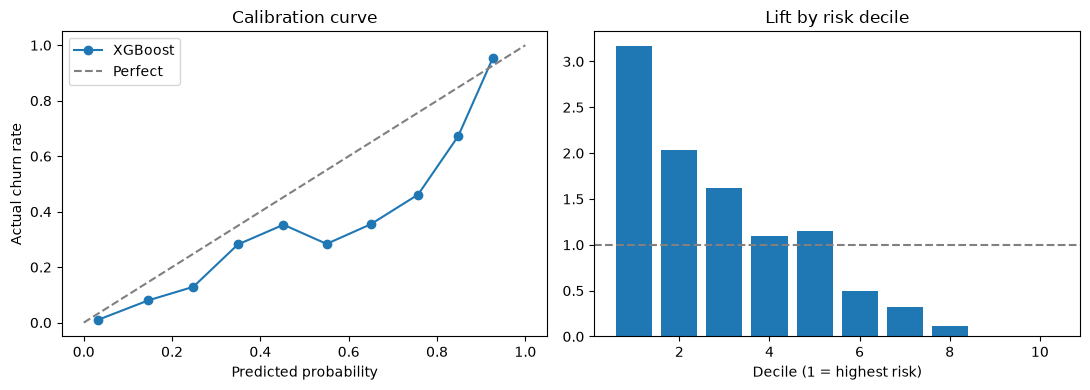

In [74]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

final_model = xgb  # already fitted inside evaluate()
proba_val = final_model.predict_proba(X_val)[:, 1]

# --- top-decile lift ---
val = pd.DataFrame({"y": y_val.values, "p": proba_val}).sort_values("p", ascending=False)
val["decile"] = pd.qcut(np.arange(len(val)), 10, labels=range(1, 11))
lift = val.groupby("decile", observed=True)["y"].agg(["count", "sum", "mean"])
lift["lift"] = (lift["mean"] / y_val.mean()).round(2)
print(lift.round(3))

# --- calibration + lift charts ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
frac_pos, mean_pred = calibration_curve(y_val, proba_val, n_bins=10)
axes[0].plot(mean_pred, frac_pos, marker="o", label="XGBoost")
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
axes[0].set_title("Calibration curve"); axes[0].set_xlabel("Predicted probability"); axes[0].set_ylabel("Actual churn rate"); axes[0].legend()
axes[1].bar(lift.index.astype(int), lift["lift"])
axes[1].axhline(1, color="gray", linestyle="--")
axes[1].set_title("Lift by risk decile"); axes[1].set_xlabel("Decile (1 = highest risk)")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "lift_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

Brier before: 0.1514
Brier after:  0.122


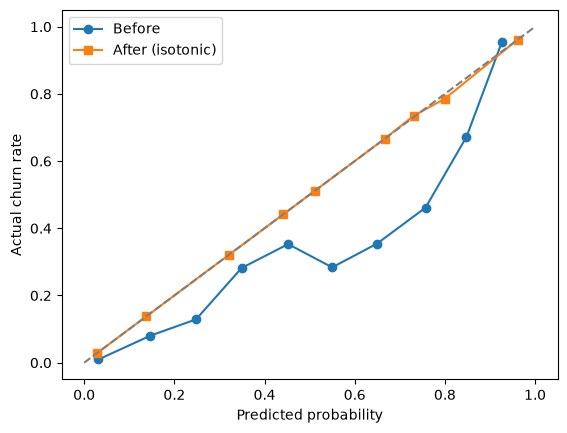

In [75]:
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss

iso = IsotonicRegression(out_of_bounds="clip", y_min=0, y_max=1)
iso.fit(proba_val, y_val)
proba_val_cal = iso.predict(proba_val)

print("Brier before:", round(brier_score_loss(y_val, proba_val), 4))
print("Brier after: ", round(brier_score_loss(y_val, proba_val_cal), 4))

frac_c, mean_c = calibration_curve(y_val, proba_val_cal, n_bins=10)
plt.plot(mean_pred, frac_pos, marker="o", label="Before")
plt.plot(mean_c, frac_c, marker="s", label="After (isotonic)")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("Predicted probability"); plt.ylabel("Actual churn rate"); plt.legend()
plt.savefig(ROOT / "reports" / "calibration_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

Best threshold: 0.10  (contacts 626 of 1056 customers)
No campaign:      $0
Contact everyone: $41,379
Model-targeted:   $47,729


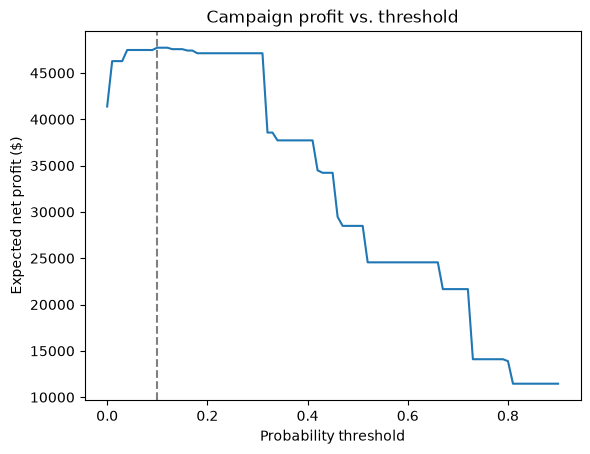

In [76]:
# ---- Assumptions (make these adjustable) ----
OFFER_COST = 20        # cost of retention offer per contacted customer
SUCCESS_RATE = 0.25    # share of would-be churners the offer actually saves
MONTHS_SAVED = 12      # months of revenue kept if saved

val_df = X_val.copy()
val_df["y"] = y_val.values
val_df["p"] = proba_val_cal
val_df["value"] = val_df["monthly_charges"] * MONTHS_SAVED   # value of saving this customer

def campaign_profit(df, contact_mask, success_rate=SUCCESS_RATE, offer_cost=OFFER_COST):
    contacted = df[contact_mask]
    # expected benefit: P(churn) x success_rate x customer value, minus offer cost
    benefit = (contacted["p"] * success_rate * contacted["value"]).sum()
    cost = offer_cost * len(contacted)
    return benefit - cost

# profit at each threshold
thresholds = np.linspace(0, 0.9, 91)
profits = [campaign_profit(val_df, val_df["p"] >= t) for t in thresholds]
best_t = thresholds[int(np.argmax(profits))]

# three strategies
no_campaign = 0
contact_all = campaign_profit(val_df, val_df["p"] >= 0)
targeted = max(profits)
n_targeted = (val_df["p"] >= best_t).sum()

print(f"Best threshold: {best_t:.2f}  (contacts {n_targeted} of {len(val_df)} customers)")
print(f"No campaign:      ${no_campaign:,.0f}")
print(f"Contact everyone: ${contact_all:,.0f}")
print(f"Model-targeted:   ${targeted:,.0f}")

plt.plot(thresholds, profits)
plt.axvline(best_t, color="gray", linestyle="--")
plt.xlabel("Probability threshold"); plt.ylabel("Expected net profit ($)")
plt.title("Campaign profit vs. threshold")
plt.savefig(ROOT / "reports" / "profit_vs_threshold.png", dpi=150, bbox_inches="tight")
plt.show()

In [77]:
rows = []
for sr in [0.10, 0.25, 0.40]:
    for oc in [10, 20, 40]:
        pf = [campaign_profit(val_df, val_df["p"] >= t, sr, oc) for t in thresholds]
        rows.append({"success_rate": sr, "offer_cost": oc,
                     "best_threshold": round(thresholds[int(np.argmax(pf))], 2),
                     "best_profit": round(max(pf)),
                     "contact_all_profit": round(campaign_profit(val_df, val_df["p"] >= 0, sr, oc))})
pd.DataFrame(rows)

,success_rate,offer_cost,best_threshold,best_profit,contact_all_profit
0,0.10,10,0.13,17938,14439
1,0.10,20,0.18,12816,3879
2,0.10,40,0.43,5786,-17241
3,0.25,10,0.04,54741,51939
4,0.25,20,0.10,47729,41379
5,0.25,40,0.18,37070,20259
6,0.40,10,0.04,91941,89438
7,0.40,20,0.04,84681,78878
8,0.40,40,0.13,71753,57758


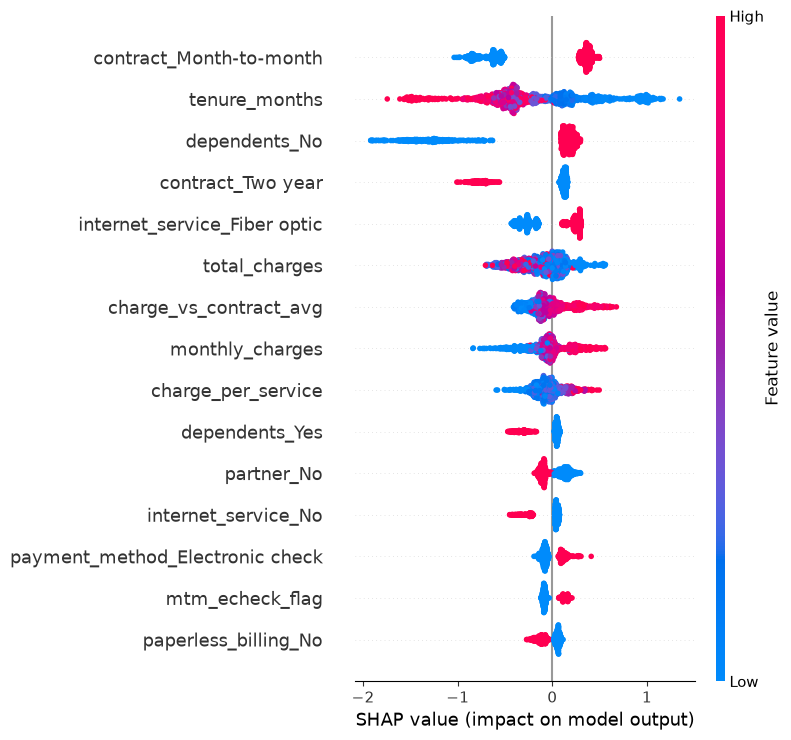

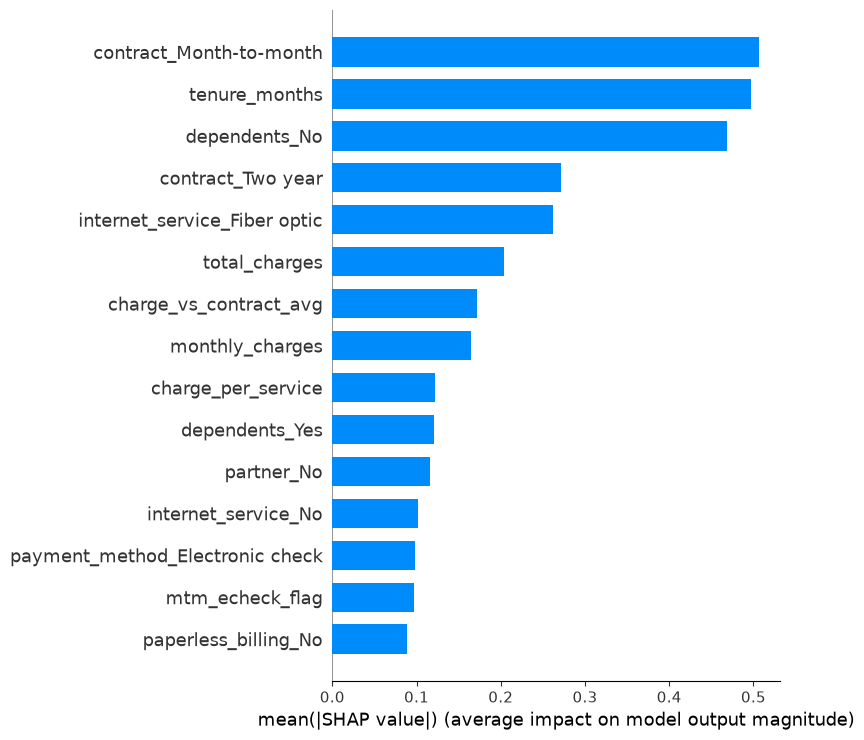

In [78]:
import shap

prep = xgb.named_steps["prep"]
clf = xgb.named_steps["clf"]

X_val_t = prep.transform(X_val)
if hasattr(X_val_t, "toarray"):
    X_val_t = X_val_t.toarray()
feature_names = [n.replace("num__", "").replace("cat__", "") for n in prep.get_feature_names_out()]
X_val_t = pd.DataFrame(X_val_t, columns=feature_names)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_val_t)

plt.figure()
shap.summary_plot(shap_values, X_val_t, max_display=15, show=False)
plt.savefig(ROOT / "reports" / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_val_t, plot_type="bar", max_display=15, show=False)
plt.savefig(ROOT / "reports" / "shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

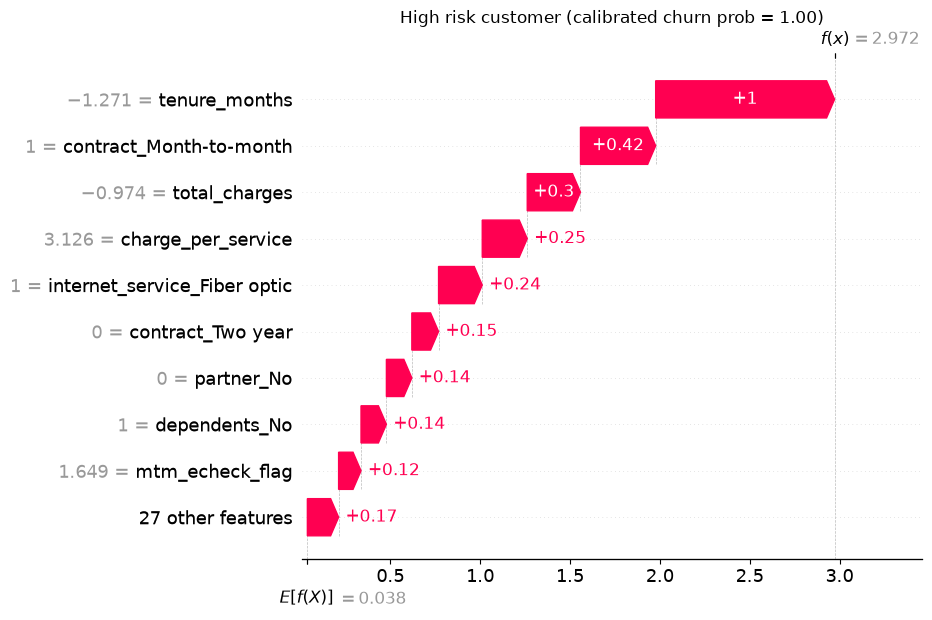

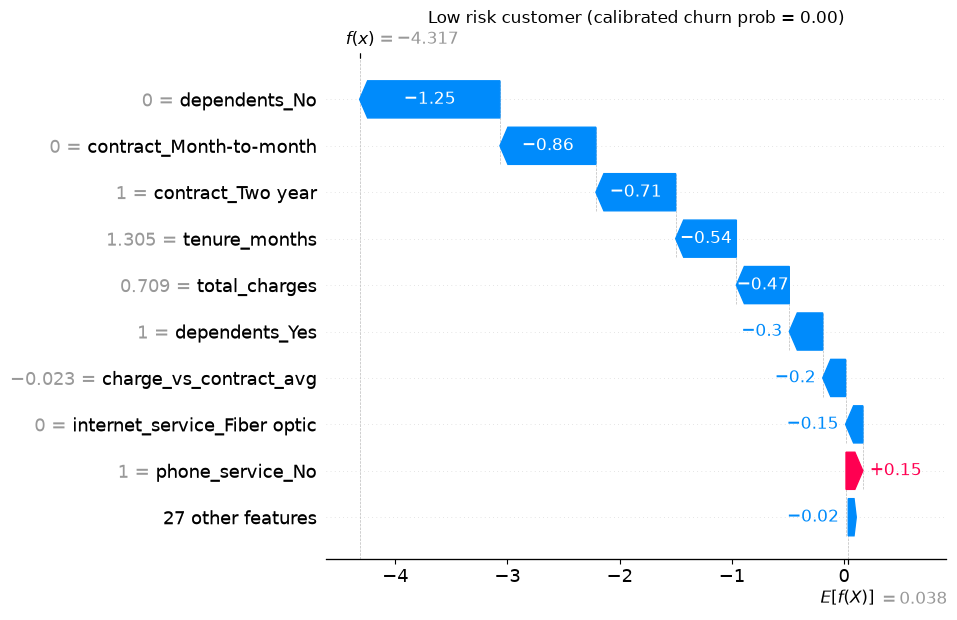

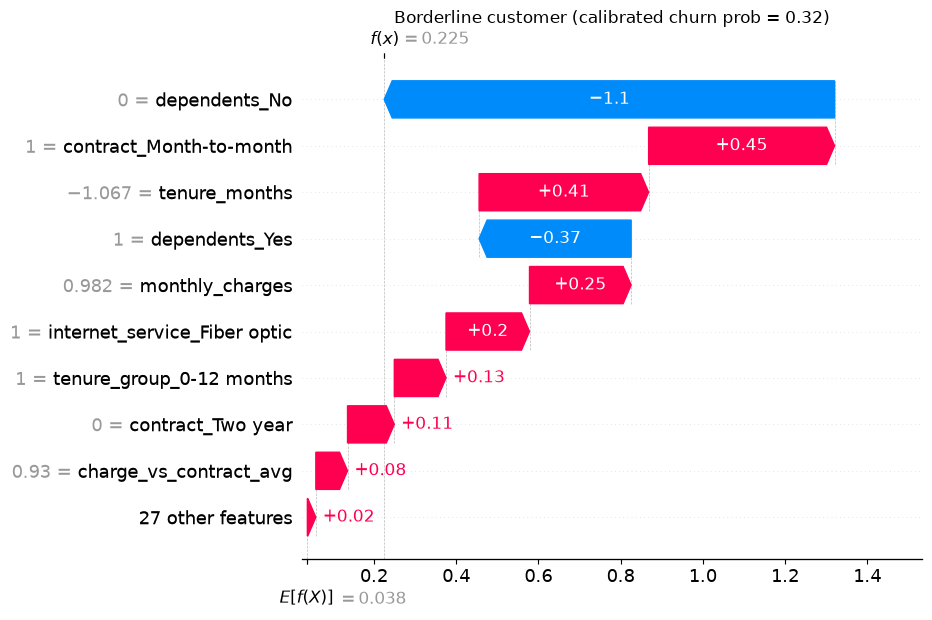

In [79]:
p = proba_val_cal
idx = {"High risk": int(np.argmax(p)),
       "Low risk": int(np.argmin(p)),
       "Borderline": int(np.argmin(np.abs(p - 0.3)))}

for label, i in idx.items():
    exp = shap.Explanation(values=shap_values[i],
                           base_values=explainer.expected_value,
                           data=X_val_t.iloc[i].values,
                           feature_names=feature_names)
    plt.figure()
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.title(f"{label} customer (calibrated churn prob = {p[i]:.2f})")
    plt.savefig(ROOT / "reports" / f"shap_waterfall_{label.replace(' ', '_').lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

In [80]:
# score ALL customers with the final model + calibrator
X_all = df.drop(columns=drop_cols)
p_all = iso.predict(xgb.predict_proba(X_all)[:, 1])

X_all_t = prep.transform(X_all)
if hasattr(X_all_t, "toarray"):
    X_all_t = X_all_t.toarray()
sv_all = explainer.shap_values(pd.DataFrame(X_all_t, columns=feature_names))

def top_drivers(row, k=3):
    idx = np.argsort(-row)[:k]
    return ", ".join(feature_names[i] for i in idx if row[i] > 0)

scored = df[["customer_id", "segment_name", "contract", "tenure_months",
             "monthly_charges", "churn_value"]].copy()
scored["churn_probability"] = p_all.round(3)
scored["risk_tier"] = pd.cut(p_all, [-0.01, 0.15, 0.40, 1.0], labels=["Low", "Medium", "High"])
scored["top_drivers"] = [top_drivers(r) for r in sv_all]
scored["revenue_at_risk"] = (scored["churn_probability"] * scored["monthly_charges"] * 12).round(2)

scored.to_csv(ROOT / "data" / "processed" / "scored_customers.csv", index=False)
scored.sort_values("revenue_at_risk", ascending=False).head(10)

,customer_id,segment_name,contract,tenure_months,monthly_charges,churn_value,churn_probability,risk_tier,top_drivers,revenue_at_risk
531,7181-BQYBV,Mid-tenure high-bill month-to-month,Month-to-month,1,102.45,1,1.000,High,"tenure_months, contract_Month-to-month, monthl...",1229.40
878,6688-UZPWD,Mid-tenure high-bill month-to-month,Month-to-month,11,102.00,1,1.000,High,"monthly_charges, charge_vs_contract_avg, contr...",1224.00
1512,5419-JPRRN,Mid-tenure high-bill month-to-month,Month-to-month,1,101.45,1,1.000,High,"tenure_months, contract_Month-to-month, charge...",1217.40
1618,1400-MMYXY,Mid-tenure high-bill month-to-month,Month-to-month,3,105.90,1,0.957,High,"tenure_months, monthly_charges, contract_Month...",1216.16
1125,3389-YGYAI,Mid-tenure high-bill month-to-month,Month-to-month,8,105.50,1,0.957,High,"contract_Month-to-month, charge_vs_contract_av...",1211.56
726,5052-PNLOS,Mid-tenure high-bill month-to-month,Month-to-month,3,105.35,1,0.957,High,"tenure_months, contract_Month-to-month, charge...",1209.84
526,7216-EWTRS,Mid-tenure high-bill month-to-month,Month-to-month,1,100.80,1,1.000,High,"tenure_months, contract_Month-to-month, total_...",1209.60
935,4587-VVTOX,Mid-tenure high-bill month-to-month,Month-to-month,6,105.30,1,0.957,High,"contract_Month-to-month, charge_vs_contract_av...",1209.27
1392,6496-SLWHQ,Mid-tenure high-bill month-to-month,Month-to-month,3,105.00,1,0.957,High,"tenure_months, contract_Month-to-month, charge...",1205.82
909,2656-TABEH,Mid-tenure high-bill month-to-month,Month-to-month,4,100.20,1,1.000,High,"charge_vs_contract_avg, tenure_months, contrac...",1202.40


In [81]:
scored[["customer_id", "churn_probability", "risk_tier", "top_drivers", "revenue_at_risk"]].sort_values("revenue_at_risk", ascending=False).head(10)
scored["risk_tier"].value_counts()

risk_tier
Low       3308
High      2030
Medium    1705
Name: count, dtype: int64

In [82]:
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score, brier_score_loss

proba_test_raw = xgb.predict_proba(X_test)[:, 1]
proba_test = iso.predict(proba_test_raw)

print("ROC-AUC:", round(roc_auc_score(y_test, proba_test_raw), 3))
print("PR-AUC: ", round(average_precision_score(y_test, proba_test_raw), 3))
print("Brier before/after calibration:",
      round(brier_score_loss(y_test, proba_test_raw), 4),
      round(brier_score_loss(y_test, proba_test), 4))

# top-decile lift
t = pd.DataFrame({"y": y_test.values, "p": proba_test_raw}).sort_values("p", ascending=False)
top = t.head(int(len(t) * 0.10))
print("Top-decile churn rate:", round(top["y"].mean(), 3),
      "| lift:", round(top["y"].mean() / y_test.mean(), 2))

# profit at the threshold chosen on validation (best_t)
test_df = X_test.copy()
test_df["p"] = proba_test
test_df["value"] = test_df["monthly_charges"] * MONTHS_SAVED
print("Test profit, targeted:", round(campaign_profit(test_df, test_df["p"] >= best_t)))
print("Test profit, contact all:", round(campaign_profit(test_df, test_df["p"] >= 0)))

ROC-AUC: 0.855
PR-AUC:  0.665
Brier before/after calibration: 0.1517 0.1364
Top-decile churn rate: 0.752 | lift: 2.83
Test profit, targeted: 45484
Test profit, contact all: 38814


In [83]:
def recommend(row):
    if row["risk_tier"] == "Low":
        return "No action"
    d = str(row["top_drivers"])
    if "tenure_months" in d and "Month-to-month" in row["contract"]:
        return "Contract upgrade offer + 30/90-day check-in"
    if "contract_Month-to-month" in d:
        return "Discount for 12-month contract"
    if "Fiber optic" in d or "charge" in d:
        return "Price/value review or bundle offer"
    if "Electronic check" in d or "paperless" in d:
        return "Auto-pay incentive"
    return "Personal outreach by retention team"

scored["recommended_action"] = scored.apply(recommend, axis=1)
scored.to_csv(ROOT / "data" / "processed" / "scored_customers.csv", index=False)
scored["recommended_action"].value_counts()

recommended_action
No action                                      3308
Discount for 12-month contract                 1753
Contract upgrade offer + 30/90-day check-in    1483
Price/value review or bundle offer              438
Personal outreach by retention team              35
Auto-pay incentive                               26
Name: count, dtype: int64

In [84]:
dash = scored.merge(
    df[["customer_id", "tenure_group", "internet_service", "payment_method",
        "num_addons", "senior_citizen"]],
    on="customer_id", how="left")
dash["high_risk_flag"] = (dash["risk_tier"] == "High").astype(int)
dash.to_csv(ROOT / "data" / "processed" / "dashboard_data.csv", index=False)

# SHAP importance table for the Drivers page
imp = pd.DataFrame({"feature": feature_names,
                    "mean_abs_shap": np.abs(shap_values).mean(axis=0)})
imp = imp.sort_values("mean_abs_shap", ascending=False).head(15)
imp.to_csv(ROOT / "reports" / "shap_importance.csv", index=False)

print(dash.shape); dash.head(3)

(7043, 17)


,customer_id,segment_name,contract,tenure_months,monthly_charges,churn_value,churn_probability,risk_tier,top_drivers,revenue_at_risk,recommended_action,tenure_group,internet_service,payment_method,num_addons,senior_citizen,high_risk_flag
0,3668-QPYBK,New low-spend month-to-month,Month-to-month,2,53.85,1,0.420,High,"tenure_months, contract_Month-to-month, total_...",271.40,Contract upgrade offer + 30/90-day check-in,0-12 months,DSL,Mailed check,2,No,1
1,9237-HQITU,New low-spend month-to-month,Month-to-month,2,70.70,1,0.462,High,"tenure_months, contract_Month-to-month, charge...",391.96,Contract upgrade offer + 30/90-day check-in,0-12 months,Fiber optic,Electronic check,0,No,1
2,9305-CDSKC,Mid-tenure high-bill month-to-month,Month-to-month,8,99.65,1,0.512,High,"charge_vs_contract_avg, contract_Month-to-mont...",612.25,Contract upgrade offer + 30/90-day check-in,0-12 months,Fiber optic,Electronic check,3,No,1
